# Train Action-Chunking-Transformer (ACT) on your Dataset
Train the ACT model on your custom dataset. In this example, we set chunk_size as 10. 

In [1]:
import torch
import sys
import numpy as np
sys.path.append('/home/student/Desktop/lerobot-papras')
from lerobot.datasets.lerobot_dataset import LeRobotDataset, LeRobotDatasetMetadata
from lerobot.datasets.dataset_tools import merge_datasets, split_dataset
from lerobot.datasets.utils import dataset_to_policy_features
from lerobot.policies.act.configuration_act import ACTConfig
from lerobot.policies.act.modeling_act import ACTPolicy
from lerobot.configs.types import FeatureType
from lerobot.datasets.factory import resolve_delta_timestamps
from torch.utils.data import ConcatDataset, Subset

/home/student/miniconda3/envs/lerobot/lib/python3.10/site-packages/torchvision/io/image.py:13: UserWarning: Failed to load image Python extension: '/home/student/miniconda3/envs/lerobot/lib/python3.10/site-packages/torchvision/image.so: undefined symbol: _ZN3c1017RegisterOperatorsD1Ev'If you don't plan on using image functionality from `torchvision.io`, you can ignore this warning. Otherwise, there might be something wrong with your environment. Did you have `libjpeg` or `libpng` installed before building `torchvision` from source?
  warn(
/home/student/miniconda3/envs/lerobot/lib/python3.10/site-packages/torchvision/datapoints/__init__.py:12: UserWarning: The torchvision.datapoints and torchvision.transforms.v2 namespaces are still Beta. While we do not expect major breaking changes, some APIs may still change according to user feedback. Please submit any feedback you may have in this issue: https://github.com/pytorch/vision/issues/6753, and you can also check out https://github.com/p

In [2]:
device = torch.device("cuda")

# Number of offline training steps (we'll only do offline training for this example.)
# Adjust as you prefer. 5000 steps are needed to get something worth evaluating.
training_steps = 5000
log_freq = 100
n_action_steps = 10
chunk_size = 10 
batch_size = 64
num_workers = 4

## Dataset Construction

In [3]:
# create a merged dataset for train/val split 
test_dataset = LeRobotDataset("nov_19e_20", root='./nov_19_e20') #20 episodes
train_dataset_1 = LeRobotDataset("dec_8_e60_v1", root='./dec_8_e60_v1') #20 episodes
train_dataset_2 = LeRobotDataset("dec_8_e60_v2", root='./dec_8_e60_v2') #20 episodes
train_dataset_3 = LeRobotDataset("dec_8_e60_v3", root='./dec_8_e60_v3') #20 episodes

In [ ]:
# Create dataets of size 20, 40, 60 and save
train_val_60 = merge_datasets([train_dataset_1, train_dataset_2, train_dataset_3], "dec_8_all", "./dec_8_all")
train_val_40 = merge_datasets([train_dataset_1, train_dataset_2], "dec_8_40", "./dec_8_40")
train_val_20 = merge_datasets([train_dataset_1], "dec_8_20", "./dec_8_20")


## Policy Configuration and Initialize


In [4]:
# When starting from scratch (i.e. not from a pretrained policy), we need to specify 2 things before
# creating the policy:
#   - input/output shapes: to properly size the policy
#   - dataset stats: for normalization and denormalization of input/outputs

# Load metadata for each of our datasets 
dataset_60_metadata = LeRobotDatasetMetadata("dec_8_all", root='./dec_8_all')
dataset_40_metadata = LeRobotDatasetMetadata("dec_8_40", root='./dec_8_40')
dataset_20_metadata = LeRobotDatasetMetadata("dec_8_20", root='./dec_8_20')

assert(dataset_60_metadata.features==dataset_40_metadata.features)
assert(dataset_60_metadata.features==test_dataset.meta.features)
assert(dataset_60_metadata.features==dataset_20_metadata.features)

features = dataset_to_policy_features(test_dataset.features)
output_features = {key: ft for key, ft in features.items() if ft.type is FeatureType.ACTION}
input_features = {key: ft for key, ft in features.items() if key not in output_features}
input_features.pop("observation.wrist_image")

# Policies are initialized with a configuration class, in this case `DiffusionConfig`. For this example,
# we'll just use the defaults and so no arguments other than input/output features need to be passed.
cfg = ACTConfig(input_features=input_features, output_features=output_features, chunk_size=chunk_size, n_action_steps=n_action_steps)

# This allows us to construct the data with action chunking
delta_timestamps = resolve_delta_timestamps(cfg, dataset_60_metadata)


## Load Datasets

In [5]:
from torchvision import transforms

class AddGaussianNoise(object):
    """
    Adds Gaussian noise to a tensor.
    """
    def __init__(self, mean=0., std=0.01):
        self.mean = mean
        self.std = std

    def __call__(self, tensor):
        # Adds noise: tensor remains a tensor.
        noise = torch.randn(tensor.size()) * self.std + self.mean
        return tensor + noise

    def __repr__(self):
        return f"{self.__class__.__name__}(mean={self.mean}, std={self.std})"

# Create a transformation pipeline that converts a PIL image to a tensor, then adds noise.
transform = transforms.Compose([
    AddGaussianNoise(mean=0., std=0.02),
    transforms.Lambda(lambda x: x.clamp(0, 1))
])


In [20]:
# We can then instantiate the dataset with these delta_timestamps configuration.
dataset_20 = LeRobotDataset("dec_8_20", delta_timestamps=delta_timestamps, root='./dec_8_20', image_transforms=transform)
dataset_40 = LeRobotDataset("dec_8_40", delta_timestamps=delta_timestamps, root='./dec_8_40', image_transforms=transform)
dataset_60 = LeRobotDataset("dec_8_all", delta_timestamps=delta_timestamps, root='./dec_8_all', image_transforms=transform)
dataset_test = LeRobotDataset("nov_19e_20", delta_timestamps=delta_timestamps, root='./nov_19_e20', image_transforms=transform)

# Then we create our optimizer and dataloader for offline training.

# Load subsets of strategies
test_strategies = np.loadtxt('./nov_19_e20/strategy.txt')

grip_inside = np.argwhere(test_strategies == 1)[:,0]
print(list(grip_inside))

grip_handle = np.argwhere(test_strategies == 0)[:,0]
print(list(grip_handle))


dataset_test_grip_inside = Subset(dataset_test, list(grip_inside))
dataset_test_grip_handle= Subset(dataset_test, list(grip_handle))

all_strategies = np.loadtxt('./dec_8_all/strategy.txt')

grip_inside = np.argwhere(all_strategies == 1)[:,0]
print(list(grip_inside))

grip_handle = np.argwhere(all_strategies == 0)[:,0]
print(list(grip_handle))

i = []
[i.extend(list(EpisodeSampler(dataset_20, idx))) for idx in list(grip_inside[grip_inside<20])]
h = []
[h.extend(list(EpisodeSampler(dataset_20, idx))) for idx in list(grip_handle[grip_handle<20])]
dataset_20_grip_inside = Subset(dataset_20, i)
dataset_20_grip_handle= Subset(dataset_20, h)

i = []
[i.extend(list(EpisodeSampler(dataset_40, idx))) for idx in list(grip_inside[grip_inside<40])]
h = []
[h.extend(list(EpisodeSampler(dataset_40, idx))) for idx in list(grip_handle[grip_handle<40])]
dataset_40_grip_inside = Subset(dataset_40, i)
dataset_40_grip_handle= Subset(dataset_40, h)

i = []
[i.extend(list(EpisodeSampler(dataset_60, idx))) for idx in list(grip_inside)]
h = []
[h.extend(list(EpisodeSampler(dataset_60, idx))) for idx in list(grip_handle)]
dataset_60_grip_inside = Subset(dataset_60, i)
dataset_60_grip_handle= Subset(dataset_60, h)

[0, 4, 5, 6, 8, 9, 10, 11, 12, 15, 17]
[1, 2, 3, 13, 16]
[2, 3, 4, 6, 7, 8, 9, 11, 12, 13, 15, 16, 20, 21, 24, 25, 27, 31, 32, 33, 36, 37, 38, 39, 43, 47, 49, 50, 51, 52, 54, 56, 57, 58]
[0, 5, 14, 19, 22, 26, 42]


Filter:   0%|          | 0/40 [00:00<?, ? examples/s]

Filter:   0%|          | 0/40 [00:00<?, ? examples/s]

Filter:   0%|          | 0/40 [00:00<?, ? examples/s]

Filter:   0%|          | 0/40 [00:00<?, ? examples/s]

...

Filter:   0%|          | 0/60 [00:00<?, ? examples/s]

Filter:   0%|          | 0/60 [00:00<?, ? examples/s]

Filter:   0%|          | 0/60 [00:00<?, ? examples/s]

Filter:   0%|          | 0/60 [00:00<?, ? examples/s]

Filter:   0%|          | 0/60 [00:00<?, ? examples/s]

In [23]:
len(dataset_60_grip_inside)

7767

In [24]:

dataloader_20_inside = torch.utils.data.DataLoader(
    dataset_20_grip_inside,
    num_workers=num_workers,
    batch_size=batch_size,
    shuffle=True,
    pin_memory=device.type != "cpu",
    drop_last=True,
)

dataloader_20_handle = torch.utils.data.DataLoader(
    dataset_20_grip_handle,
    num_workers=num_workers,
    batch_size=batch_size,
    shuffle=True,
    pin_memory=device.type != "cpu",
    drop_last=True,
)
dataloader_40_inside = torch.utils.data.DataLoader(
    dataset_40_grip_inside,
    num_workers=num_workers,
    batch_size=batch_size,
    shuffle=True,
    pin_memory=device.type != "cpu",
    drop_last=True,
)

dataloader_40_handle = torch.utils.data.DataLoader(
    dataset_40_grip_handle,
    num_workers=num_workers,
    batch_size=batch_size,
    shuffle=True,
    pin_memory=device.type != "cpu",
    drop_last=True,
)

dataloader_60_inside = torch.utils.data.DataLoader(
    dataset_60_grip_inside,
    num_workers=num_workers,
    batch_size=batch_size,
    shuffle=True,
    pin_memory=device.type != "cpu",
    drop_last=True,
)

dataloader_60_handle = torch.utils.data.DataLoader(
    dataset_60_grip_handle,
    num_workers=num_workers,
    batch_size=batch_size,
    shuffle=True,
    pin_memory=device.type != "cpu",
    drop_last=True,
)

print(len(dataloader_20_inside), len(dataloader_40_inside), len(dataloader_60_inside))

45 88 121


In [16]:
class EpisodeSampler(torch.utils.data.Sampler):
    """
    Sampler for a single episode
    """
    def __init__(self, dataset: LeRobotDataset, episode_index: int):
        episode = dataset.meta.episodes.filter(lambda example: example["episode_index"]==episode_index)[0]
        from_idx = episode["dataset_from_index"],
        to_idx = episode["dataset_to_index"]
        # print(from_idx, to_idx)
        self.frame_ids = range(from_idx[0], to_idx)

    def __iter__(self):
        return iter(self.frame_ids)

    def __len__(self) -> int:
        return len(self.frame_ids)
        

## 20 Episode Dataset Policy

### Training

The trained checkpoint will be saved in './ckpt/act_y' folder.

In [50]:
lr = 5e-4

In [51]:
# We can now instantiate our policy with this config and the dataset stats.
policy_20 = ACTPolicy(cfg)
policy_20.train()
policy_20.to(device)

optimizer = torch.optim.Adam(policy_20.parameters(), lr=lr)

In [ ]:
# Run training loop.
step = 0
done = False

while not done:
    for batch in dataloader_20_inside:
        inp_batch = {k: (v.to(device) if isinstance(v, torch.Tensor) else v) for k, v in batch.items()}
        loss, _ = policy_20.forward(inp_batch)
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        if step % log_freq == 0:
            print(f"step: {step} loss: {loss.item():.3f}")
        step += 1
        if step >= training_steps:
            done = True
            break


step: 0 loss: 60.561


In [ ]:
# Save the policy to disk.
policy_20.save_pretrained('./ckpt/act_20_inside_lr5')

### Test Inference

To evaluate the policy on the dataset, you can calculate the error between ground-truth actions from the dataset.

In [ ]:
policy_20.eval()
actions = []
gt_actions = []
images = []
episode_index = 4
episode_sampler = EpisodeSampler(dataset_test, episode_index)

test_dataloader = torch.utils.data.DataLoader(
    dataset_test,
    num_workers=4,
    batch_size=1,
    shuffle=False,
    pin_memory=device.type != "cpu",
    sampler=episode_sampler,
)
policy_20.reset()
for batch in test_dataloader:
    inp_batch = {k: (v.to(device) if isinstance(v, torch.Tensor) else v) for k, v in batch.items()}
    action = policy_20.select_action(inp_batch)
    actions.append(action)
    gt_actions.append(inp_batch["action"][:,0,:])
    images.append(inp_batch["observation.image"])
actions = torch.cat(actions, dim=0)
gt_actions = torch.cat(gt_actions, dim=0)
print(f"Mean action error: {torch.mean(torch.abs(actions - gt_actions)).item():.3f}")

Mean action error: 0.161


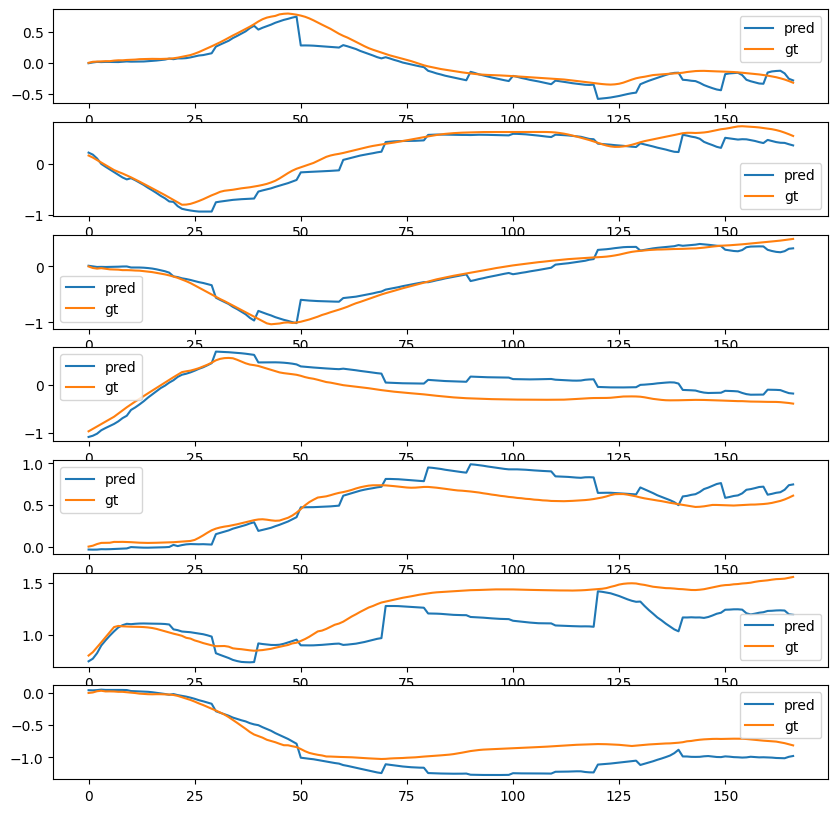

In [ ]:
'''
plot actions and gt_actions
'''
import matplotlib.pyplot as plt
action_dim = 7

fig, axs = plt.subplots(action_dim, 1, figsize=(10, 10))
# plt.title("ACT 20 episode dataset performance")
for i in range(action_dim):
    axs[i].plot(actions[:, i].cpu().detach().numpy(), label="pred")
    axs[i].plot(gt_actions[:, i].cpu().detach().numpy(), label="gt")
    axs[i].legend()
plt.show()

## 40 Episode Dataset Policy

### Training

The trained checkpoint will be saved in './ckpt/act_y' folder.

In [33]:
# We can now instantiate our policy with this config and the dataset stats.
policy_40 = ACTPolicy(cfg)
policy_40.train()
policy_40.to(device)

optimizer = torch.optim.Adam(policy_40.parameters(), lr=lr)

In [34]:
# Run training loop.
step = 0
done = False

while not done:
    for batch in dataloader_40_inside:
        inp_batch = {k: (v.to(device) if isinstance(v, torch.Tensor) else v) for k, v in batch.items()}
        loss, _ = policy_40.forward(inp_batch)
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        if step % log_freq == 0:
            print(f"step: {step} loss: {loss.item():.3f}")
        step += 1
        if step >= training_steps:
            done = True
            break


step: 0 loss: 105.981
step: 100 loss: 2.588
step: 200 loss: 1.895
step: 300 loss: 1.306
step: 400 loss: 0.943
step: 500 loss: 0.730
step: 600 loss: 0.516
step: 700 loss: 0.420
step: 800 loss: 0.341
step: 900 loss: 0.280
step: 1000 loss: 0.253
step: 1100 loss: 0.226
step: 1200 loss: 0.192
step: 1300 loss: 0.171
step: 1400 loss: 0.161
step: 1500 loss: 0.152
step: 1600 loss: 0.143
step: 1700 loss: 0.143
step: 1800 loss: 0.137
step: 1900 loss: 0.125
step: 2000 loss: 0.115
step: 2100 loss: 0.105
step: 2200 loss: 0.111
step: 2300 loss: 0.100
step: 2400 loss: 0.095
step: 2500 loss: 0.092
step: 2600 loss: 0.096
step: 2700 loss: 0.091
step: 2800 loss: 0.084
step: 2900 loss: 0.080
step: 3000 loss: 0.078
step: 3100 loss: 0.074
step: 3200 loss: 0.069
step: 3300 loss: 0.070
step: 3400 loss: 0.066
step: 3500 loss: 0.063
step: 3600 loss: 0.062
step: 3700 loss: 0.070
step: 3800 loss: 0.059
step: 3900 loss: 0.058
step: 4000 loss: 0.055
step: 4100 loss: 0.053
step: 4200 loss: 0.054
step: 4300 loss: 0.04

In [ ]:
# Save the policy to disk.
policy_40.save_pretrained('./ckpt/act_40_inside_lr_001')

### Test Inference

To evaluate the policy on the dataset, you can calculate the error between ground-truth actions from the dataset.

In [37]:
policy_40.eval()
actions = []
gt_actions = []
images = []
episode_index = 4
episode_sampler = EpisodeSampler(dataset_test, episode_index)

test_dataloader = torch.utils.data.DataLoader(
    dataset_test,
    num_workers=4,
    batch_size=1,
    shuffle=False,
    pin_memory=device.type != "cpu",
    sampler=episode_sampler,
)
policy_40.reset()
for batch in test_dataloader:
    inp_batch = {k: (v.to(device) if isinstance(v, torch.Tensor) else v) for k, v in batch.items()}
    action = policy_40.select_action(inp_batch)
    actions.append(action)
    gt_actions.append(inp_batch["action"][:,0,:])
    images.append(inp_batch["observation.image"])
actions = torch.cat(actions, dim=0)
gt_actions = torch.cat(gt_actions, dim=0)
print(f"Mean action error: {torch.mean(torch.abs(actions - gt_actions)).item():.3f}")

Mean action error: 0.130


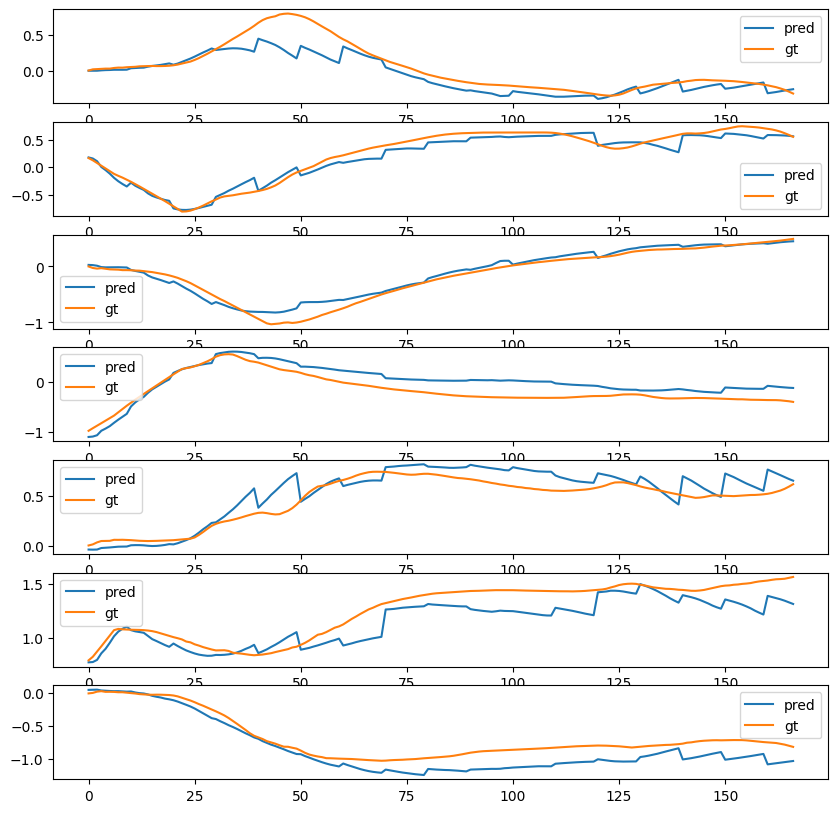

In [38]:
'''
plot actions and gt_actions
'''
import matplotlib.pyplot as plt
action_dim = 7

fig, axs = plt.subplots(action_dim, 1, figsize=(10, 10))
# plt.title("ACT 20 episode dataset performance")
for i in range(action_dim):
    axs[i].plot(actions[:, i].cpu().detach().numpy(), label="pred")
    axs[i].plot(gt_actions[:, i].cpu().detach().numpy(), label="gt")
    axs[i].legend()
plt.show()

## 60 Episode Dataset Policy

### Training

The trained checkpoint will be saved in './ckpt/act_y' folder.

In [39]:
# We can now instantiate our policy with this config and the dataset stats.
policy_60 = ACTPolicy(cfg)
policy_60.train()
policy_60.to(device)

optimizer = torch.optim.Adam(policy_60.parameters(), lr=lr)

In [40]:
# Run training loop.
step = 0
done = False

while not done:
    for batch in dataloader_60_inside:
        inp_batch = {k: (v.to(device) if isinstance(v, torch.Tensor) else v) for k, v in batch.items()}
        loss, _ = policy_60.forward(inp_batch)
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        if step % log_freq == 0:
            print(f"step: {step} loss: {loss.item():.3f}")
        step += 1
        if step >= training_steps:
            done = True
            break


step: 0 loss: 60.771
step: 100 loss: 2.239
step: 200 loss: 1.680
step: 300 loss: 1.251
step: 400 loss: 0.977
step: 500 loss: 0.680
step: 600 loss: 0.500
step: 700 loss: 0.387
step: 800 loss: 0.319
step: 900 loss: 0.282
step: 1000 loss: 0.237
step: 1100 loss: 0.215
step: 1200 loss: 0.204
step: 1300 loss: 0.181
step: 1400 loss: 0.174
step: 1500 loss: 0.157
step: 1600 loss: 0.159
step: 1700 loss: 0.145
step: 1800 loss: 0.131
step: 1900 loss: 0.123
step: 2000 loss: 0.121
step: 2100 loss: 0.114
step: 2200 loss: 0.104
step: 2300 loss: 0.104
step: 2400 loss: 0.100
step: 2500 loss: 0.102
step: 2600 loss: 0.091
step: 2700 loss: 0.090
step: 2800 loss: 0.089
step: 2900 loss: 0.084
step: 3000 loss: 0.080
step: 3100 loss: 0.076
step: 3200 loss: 0.082
step: 3300 loss: 0.080
step: 3400 loss: 0.071
step: 3500 loss: 0.067
step: 3600 loss: 0.069
step: 3700 loss: 0.064
step: 3800 loss: 0.060
step: 3900 loss: 0.061
step: 4000 loss: 0.057
step: 4100 loss: 0.061
step: 4200 loss: 0.058
step: 4300 loss: 0.060

In [41]:
# Save the policy to disk.
policy_60.save_pretrained('./ckpt/act_60_inside')

### Test Inference

To evaluate the policy on the dataset, you can calculate the error between ground-truth actions from the dataset.

In [42]:
policy_60.eval()
actions = []
gt_actions = []
images = []
episode_index = 4
episode_sampler = EpisodeSampler(dataset_test, episode_index)

test_dataloader = torch.utils.data.DataLoader(
    dataset_test,
    num_workers=4,
    batch_size=1,
    shuffle=False,
    pin_memory=device.type != "cpu",
    sampler=episode_sampler,
)
policy_60.reset()
for batch in test_dataloader:
    inp_batch = {k: (v.to(device) if isinstance(v, torch.Tensor) else v) for k, v in batch.items()}
    action = policy_60.select_action(inp_batch)
    actions.append(action)
    gt_actions.append(inp_batch["action"][:,0,:])
    images.append(inp_batch["observation.image"])
actions = torch.cat(actions, dim=0)
gt_actions = torch.cat(gt_actions, dim=0)
print(f"Mean action error: {torch.mean(torch.abs(actions - gt_actions)).item():.3f}")

Mean action error: 0.090


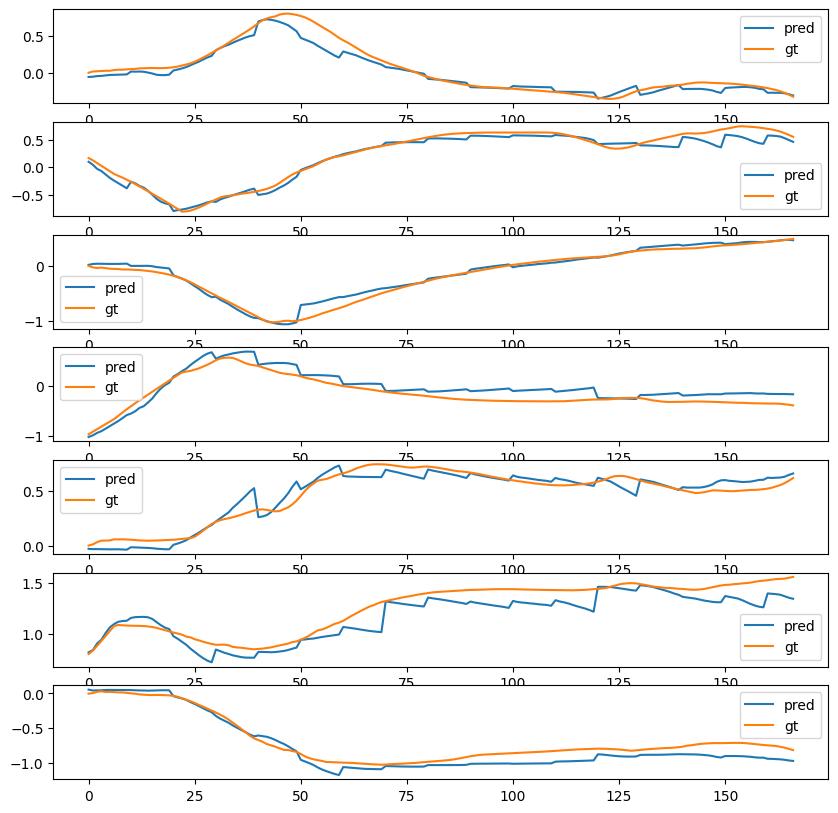

In [43]:
'''
plot actions and gt_actions
'''
import matplotlib.pyplot as plt
action_dim = 7

fig, axs = plt.subplots(action_dim, 1, figsize=(10, 10))
# plt.title("ACT 20 episode dataset performance")
for i in range(action_dim):
    axs[i].plot(actions[:, i].cpu().detach().numpy(), label="pred")
    axs[i].plot(gt_actions[:, i].cpu().detach().numpy(), label="gt")
    axs[i].legend()
plt.show()